# Project results.

The purpose of this notebook is to present the results of the project and highlight the most important results.

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


In [3]:
df = pd.read_csv("collected_metrics.csv")

In [4]:
# Extract processing type ('top' vs 'dim_red') into a new column for faceting
df['processing_type'] = df['model_name'].apply(
    lambda x: 'Top Features' if 'top' in x else 'Dimensionality Reduction'
)

# 3. Standardize capitalization in feature_type for cleaner axis labels
df['feature_type'] = df['feature_type'].str.capitalize()
df['feature_type'] = df['feature_type'].replace('Tfidf', 'TF-IDF')

# 4. Define a consistent color palette for the classifiers
clf_palette = {
    'LinearSVC': '#1f77b4', 
    'LogisticRegression': '#ff7f0e', 
    'XGBoost': '#2ca02c'
}

sns.set_theme(style="whitegrid")

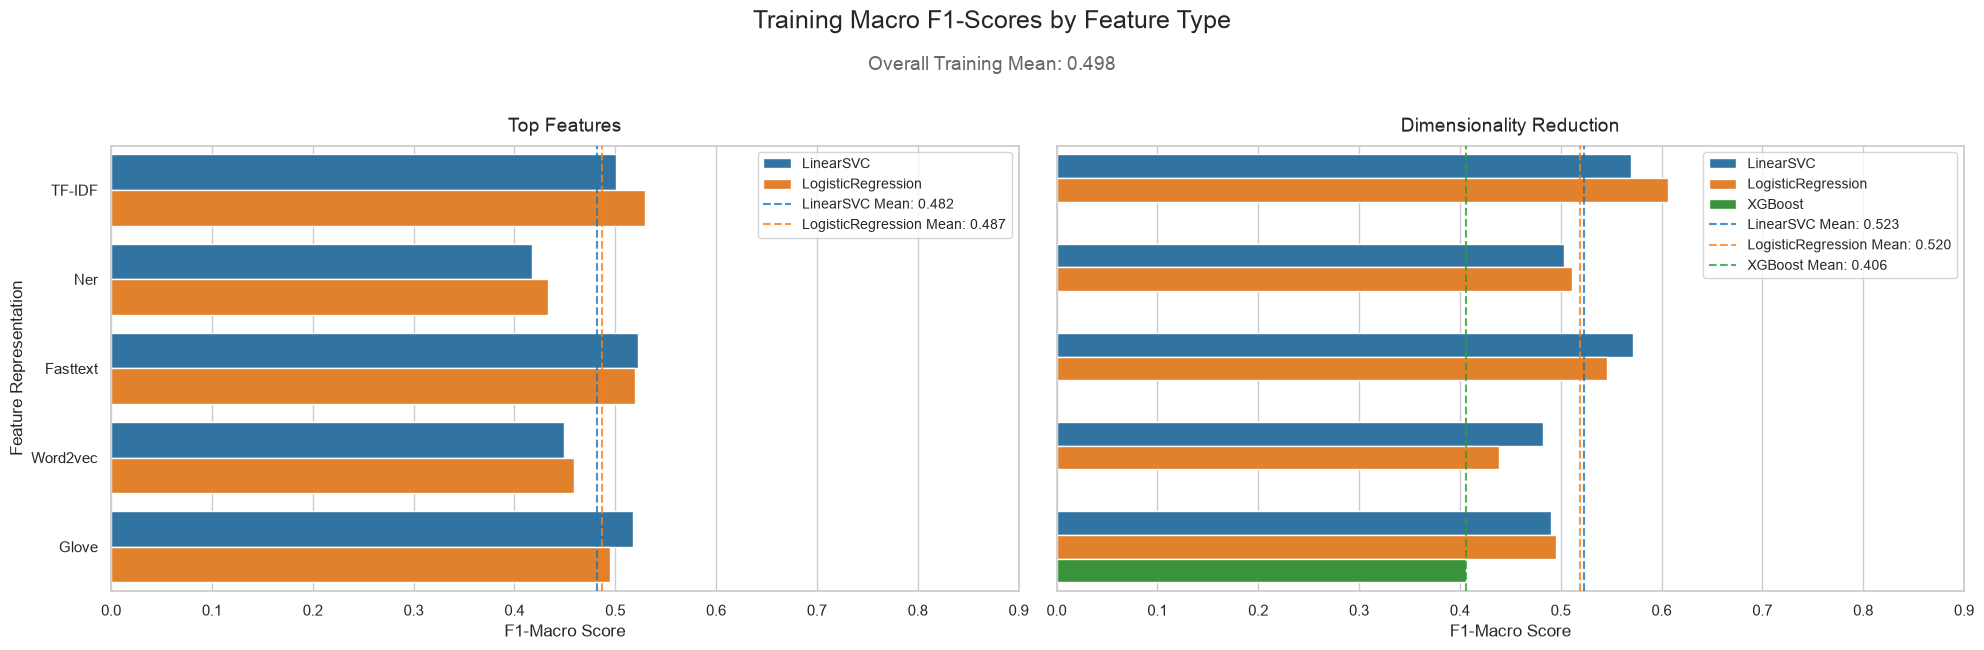

In [12]:
# ==========================================
# PLOT 1: TRAINING F1-MACRO SCORES
# ==========================================
train_df = df[df['mode'] == 'training'].copy()
overall_train_mean = train_df['f1_macro'].mean()

fig1, axes1 = plt.subplots(1, 2, figsize=(20, 6), sharey=True)

# Main Title and Overall Mean Caption
fig1.suptitle('Training Macro F1-Scores by Feature Type', fontsize=18, y=1.08)
fig1.text(0.5, 0.98, f"Overall Training Mean: {overall_train_mean:.3f}", ha='center', fontsize=14, color='dimgray')

for idx, proc_type in enumerate(['Top Features', 'Dimensionality Reduction']):
    subset = train_df[train_df['processing_type'] == proc_type]
    
    # Plot the horizontal bar chart
    sns.barplot(
        data=subset, 
        y='feature_type', 
        x='f1_macro', 
        hue='classifier', 
        palette=clf_palette,
        ax=axes1[idx]
    )
    
    # Calculate and plot the mean vertical line per classifier
    for clf in subset['classifier'].unique():
        clf_mean = subset[subset['classifier'] == clf]['f1_macro'].mean()
        axes1[idx].axvline(
            x=clf_mean, 
            color=clf_palette[clf], 
            linestyle='--', 
            alpha=0.8, 
            zorder=3,
            label=f'{clf} Mean: {clf_mean:.3f}' # Adds the line value to the legend
        )
    
    # Formatting
    axes1[idx].set_title(proc_type, fontsize=14, pad=10)
    axes1[idx].set_xlabel('F1-Macro Score', fontsize=12)
    axes1[idx].set_xlim(0, 0.9) 
    
    # Update legend to include both the bars and our new mean lines
    handles, labels = axes1[idx].get_legend_handles_labels()
    axes1[idx].legend(handles, labels, loc='upper right', fontsize=10)
    
axes1[0].set_ylabel('Feature Representation', fontsize=12)
axes1[1].set_ylabel('')

plt.tight_layout()
plt.savefig(
    "../plots/model_training_visuals.png",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

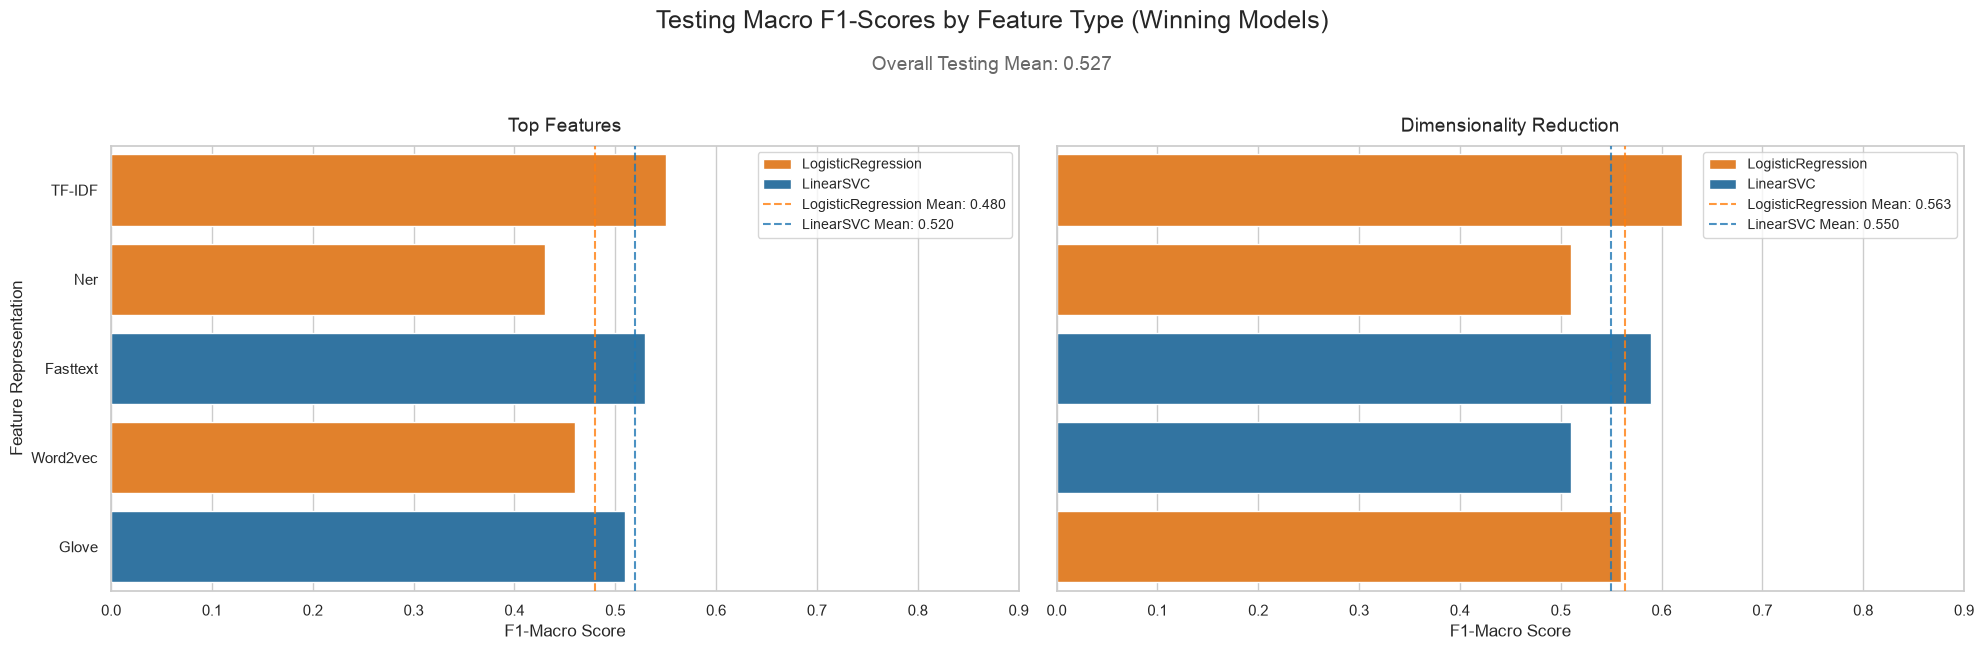

In [13]:
# ==========================================
# PLOT 2: TESTING F1-MACRO SCORES
# ==========================================
test_df = df[df['mode'] == 'testing'].copy()
overall_test_mean = test_df['f1_macro'].mean()

fig2, axes2 = plt.subplots(1, 2, figsize=(20, 6), sharey=True)

# Main Title and Overall Mean Caption
fig2.suptitle('Testing Macro F1-Scores by Feature Type (Winning Models)', fontsize=18, y=1.08)
fig2.text(0.5, 0.98, f"Overall Testing Mean: {overall_test_mean:.3f}", ha='center', fontsize=14, color='dimgray')

for idx, proc_type in enumerate(['Top Features', 'Dimensionality Reduction']):
    subset = test_df[test_df['processing_type'] == proc_type]
    
    # Plot the horizontal bar chart
    sns.barplot(
        data=subset, 
        y='feature_type', 
        x='f1_macro', 
        hue='classifier', 
        palette=clf_palette,
        ax=axes2[idx]
    )
    
    # Calculate and plot the mean vertical line per classifier
    for clf in subset['classifier'].unique():
        clf_mean = subset[subset['classifier'] == clf]['f1_macro'].mean()
        axes2[idx].axvline(
            x=clf_mean, 
            color=clf_palette[clf], 
            linestyle='--', 
            alpha=0.8, 
            zorder=3,
            label=f'{clf} Mean: {clf_mean:.3f}'
        )
    
    # Formatting
    axes2[idx].set_title(proc_type, fontsize=14, pad=10)
    axes2[idx].set_xlabel('F1-Macro Score', fontsize=12)
    axes2[idx].set_xlim(0, 0.9) 
    
    # Safely merge legend handles
    handles, labels = axes2[idx].get_legend_handles_labels()
    axes2[idx].legend(handles, labels, loc='upper right', fontsize=10)

axes2[0].set_ylabel('Feature Representation', fontsize=12)
axes2[1].set_ylabel('')

plt.tight_layout()
plt.savefig(
    "../plots/model_testing_visuals.png",
    dpi=600,
    bbox_inches="tight"
)
plt.show()